In [1]:
from uspas_llrf import LLRFApp
from pprint import pprint
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

%load_ext autoreload
%autoreload 2

# LLRF demo for AWA setting

## Setup clock input

Here is an example at LBNL to set the external clock and MO signals:

Connect 1320 MHz, 0dBm to zest clock input

In [2]:
!python3 -m uspas_llrf.tools.erasynth_micro -p /dev/ttyACM1 -f 1320e6

Read  Temperature [C]: 41.3750
Wrote Frequency [MHz]: 1320.0


## Setup PRL signal

In [3]:
#!python3 -m uspas_llrf.tools.erasynth_micro -p /dev/ttyACM1 -f 20e6 -a 10

Read  Temperature [C]: 42.3125
Wrote Frequency [MHz]: 20.0
Wrote Amplitude [dBm]: 10.0


## Program bitstream file

In [4]:
!make -C ../../top/marble_zest/ system_config MARBLE_SERIAL=42 BITSTREAM=marble_zest_top_AWA.8789038f.bit

make: Entering directory '/home/qdu/work/uspas_llrf/top/marble_zest'
Makefile:41: warning: overriding recipe for target '../../llrf_dsp/llrf_shell.json'
../../soc/marble_zest/common/llrf/rules.mk:12: warning: ignoring old recipe for target '../../llrf_dsp/llrf_shell.json'
Using Marble with serial number 42
openocd \
-c "adapter serial 000042;" \
-f marble.cfg \
-c "init; xc7_program xc7.tap; pld load 0 marble_zest_top_AWA.8789038f.bit; exit"
Open On-Chip Debugger 0.12.0+dev-00519-gb6ee13720-dirty (2025-07-15-02:38)
Licensed under GNU GPL v2
For bug reports, read
	http://openocd.org/doc/doxygen/bugs.html
Info : auto-selecting first available session transport "jtag". To override use 'transport select <transport>'.
fpga_program
Info : ftdi: if you experience problems at higher adapter clocks, try the command "ftdi tdo_sample_edge falling"
Info : clock speed 15000 kHz
Info : JTAG tap: xc7.tap tap/device found: 0x0364c093 (mfg: 0x049 (Xilinx), part: 0x364c, ver: 0x0)
Info : [xc7.proxy] Exa

# Read Board Support info

In [7]:
llrf = LLRFApp(addr='192.168.19.42:803',
               conf='AWA',
               chan_keep=0b1011)
llrf.get_bsp_info()

Marble Variant: V1.3
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :    -23.5 mV
  Power      :     15.7 mW
  Vbus       :     11.8 V
  Current    :  -1055.4 mA
INA219 U17, FMC1:
  Vshunt     :     23.5 mV
  Power      :     49.9 mW
  Vbus       :     11.7 V
  Current    :    187.2 mA
INA219 U32, FMC2:
  Vshunt     :    -17.8 mV
  Power      :     49.1 mW
  Vbus       :     11.7 V
  Current    :    119.9 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01001111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
QSFP 2 is present:
  Vendor     :    AVAGO           
  Part       :    AFBR-79EQDZ     
  Serial     :    QH3201VZ        
  TXRX_LOS   :    11111111
  Temp       :    46 C
  Volt       :    3260 mV
  TxBias0    :    0 uA
  TxPwr0     :    0 uW
  RxPwr0     :    0 uW
  TxBias1    :    0 uA
  TxPwr1     :    0 uW
  RxPwr1     :    0 uW
  TxBias2    :    0 uA
  TxPwr2     :    0 

## Measure a snapshot of RF amplitude and phases

Match LBNL test rack cables connections:
* DAC0 -> ADC1
* DAC1 -> ADC3
* MO -> ADC0

In [8]:
prl_adc_chan, loop0_adc_chan, loop1_adc_chan = 0, 1, 3
llrf.reg_write([
    ('prl_adc_chan', prl_adc_chan),
    ('loop0_adc_chan', loop0_adc_chan),
    ('loop1_adc_chan', loop1_adc_chan),
])

LLRFApp.init_open_loop_demo() forces CW mode, and bypass all interlocks!

In [9]:
llrf.init_cw_demo()
llrf.init_loop('loop0', amp_setp_adc=3e4)
llrf.init_loop('loop1', amp_setp_adc=3e4)
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,31514,48,38226.855845,0.131836
adc1,7,65520,8.491083,179.956055
adc2,0,-32458,0.000000,0.000000
adc3,5,-44905,6.065059,-123.335266
adc4,0,-49138,0.000000,-0.000000
adc5,2,-49138,2.426024,-134.961548
adc6,0,-65226,0.000000,-0.000000
adc7,2,-65226,2.426024,-179.148560
drv0,13983,-19365,29998.767390,-0.005743
drv1,13983,-19365,29998.767390,-0.005743


Confirm MO phase is aligned

In [10]:
assert -0.2 < df_mon['Phs [deg]'][f'adc{prl_adc_chan}'] < 0.2

## Plot raw DAC / ADC data

In [11]:
loop0_adc = f'adc{loop0_adc_chan}'
loop1_adc = f'adc{loop1_adc_chan}'
df_sig = llrf.get_raw_bufs_df()

`IF_dac` is 145.0 MHz, `f_dsp` is 94.28 MHz,
direct loop back will result in a alias frequency at 94.28-(145-94.28) = 43.56 MHz

ADC1 max: -21.186 dBFS at 43.600 MHz
ADC3 max: -15.873 dBFS at 43.588 MHz


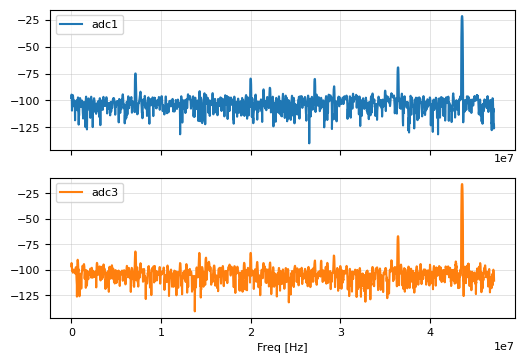

In [12]:
cols = [loop0_adc, loop1_adc]
df_psd = llrf.calc_psd_df(df_sig)
df_psd[cols].plot(subplots=True);
print(f'ADC1 max: {df_psd.adc1.max():.3f} dBFS at {df_psd.adc1.idxmax()/1e6:.3f} MHz')
print(f'ADC3 max: {df_psd.adc3.max():.3f} dBFS at {df_psd.adc3.idxmax()/1e6:.3f} MHz')

Note: Due to DAC in Mix Mode, changing IF frequency to 20MHz will significantly lower the output power.

## Loopback test

Due to lack of analog RF mixers, set IF_dac == IF_adc = 20 MHz for direct loop back test.

In [23]:
llrf = LLRFApp(addr='192.168.19.42:803',
               conf='AWA',
               loopback_test=True,
               chan_keep=0b1011)

IF loop back testing: IF_dac equals IF_adc.


In [24]:
llrf.init_cw_demo()
llrf.init_loop('loop0', amp_setp_adc=3e4)
llrf.init_loop('loop1', amp_setp_adc=3e4)
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,31541,96,38259.607165,0.263672
adc1,2211,29007,2681.969229,79.670105
adc2,2,-49138,2.426024,-134.961548
adc3,2003,34039,2429.662761,93.490906
adc4,0,-49138,0.000000,-0.000000
adc5,2,-49138,2.426024,-134.961548
adc6,0,-32458,0.000000,0.000000
adc7,2,-65226,2.426024,-179.148560
drv0,13983,-29790,29998.767390,-0.002497
drv1,13983,-29790,29998.767390,-0.002497


In [25]:
df_sig = llrf.get_raw_bufs_df()
# df_sig[[loop0_adc, loop1_adc]].loc[:5000].plot(subplots=True);

ADC1 max: -21.730 dBFS at 20.003 MHz
ADC3 max: -22.586 dBFS at 20.003 MHz


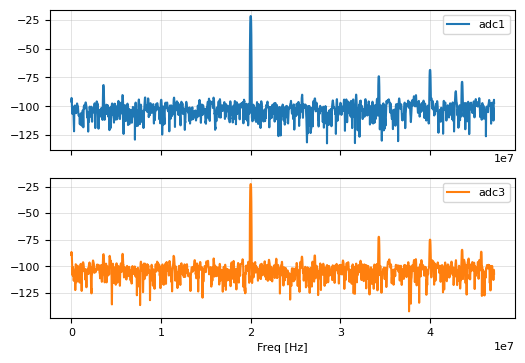

In [26]:
cols = [loop0_adc, loop1_adc]
df_psd = llrf.calc_psd_df(df_sig)
df_psd[cols].plot(subplots=True);
print(f'ADC1 max: {df_psd.adc1.max():.3f} dBFS at {df_psd.adc1.idxmax()/1e6:.3f} MHz')
print(f'ADC3 max: {df_psd.adc3.max():.3f} dBFS at {df_psd.adc3.idxmax()/1e6:.3f} MHz')

Note: Due to DAC in Mix Mode, changing IF frequency to 20MHz will significantly lower the output power.

# Pulse mode test

In [27]:
# generate 4µs pulse
fs = llrf.fs / 1e9
start0 = 0
length0 = int(4000 * fs)
start1 = 500 * fs
length1 = int(5000 * fs)
llrf.reg_write([
    ('loop0_pulse_start', start0),
    ('loop0_pulse_high_len', length0),
    ('loop1_pulse_start', start1),
    ('loop1_pulse_high_len', length1),
    ('pulse_modes', 0b11)
])

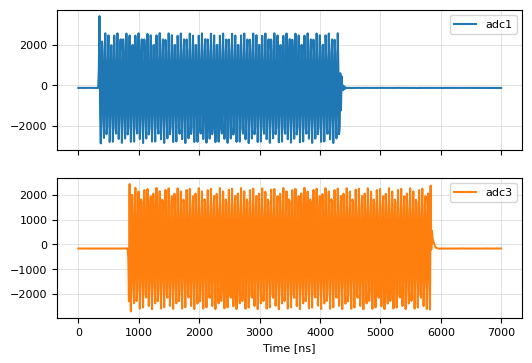

In [28]:
len_ns = 7000
df_sig = llrf.get_raw_bufs_df()
df_sig[[loop0_adc, loop1_adc]].loc[:len_ns].plot(subplots=True);

Get base band IQ waveforms

In [29]:
df_iq = llrf.get_iq_wfms_df()

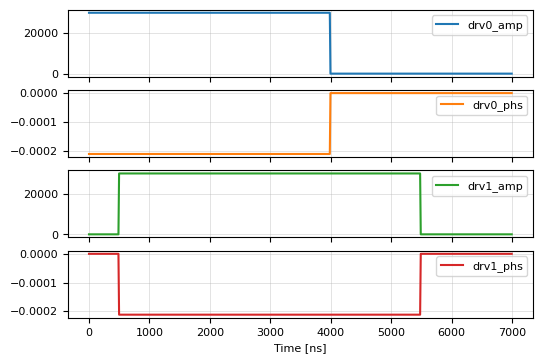

In [30]:
df_iq[['drv0_amp', 'drv0_phs', 'drv1_amp', 'drv1_phs']].loc[:len_ns].plot(subplots=True);

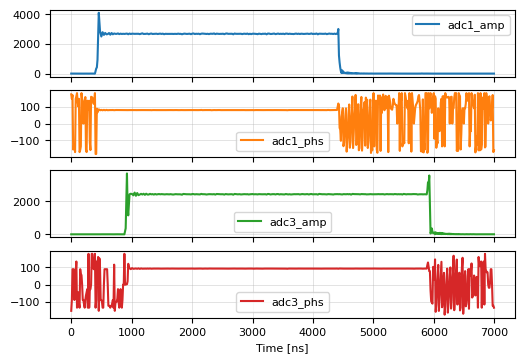

In [31]:
cols = [
    loop0_adc+'_amp', loop0_adc+'_phs',
    loop1_adc+'_amp', loop1_adc+'_phs'
]
df_iq[cols].loc[:len_ns].plot(subplots=True);

Verify IQ waveform signal gain:

In [32]:

amp = df_iq[[loop0_adc + '_amp']].loc[1500:4000].values.mean()
phs = df_iq[[loop0_adc + '_phs']].loc[1500:4000].values.mean()
print(f'fdbk_adc IQ waveform signal: amp = {amp:8.3f} cnt, phs = {phs:8.3f} deg')

amp_exp = df_mon['Amp [cnt]'][loop0_adc]
phs_exp = df_mon['Phs [deg]'][loop0_adc]
print(f'fdbk_adc expected inlk_mon:  amp = {amp_exp:8.3f} cnt, '
      f'phs = {phs_exp:8.3f} deg')

fdbk_adc IQ waveform signal: amp = 2684.579 cnt, phs =   79.682 deg
fdbk_adc expected inlk_mon:  amp = 2681.969 cnt, phs =   79.670 deg


## Plot CIC circular buffer data

In [33]:
df_mp = llrf.get_cic_wfm_df()

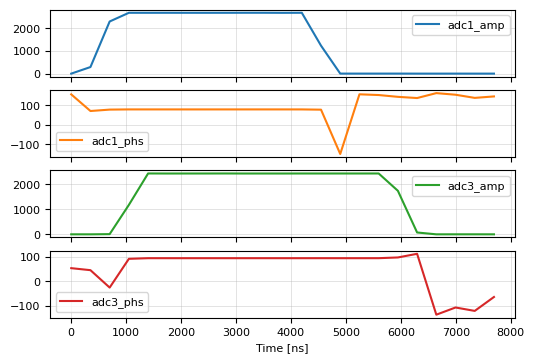

In [34]:
len_ns = 8000
df_mp[cols].loc[:len_ns].plot(subplots=True);